cpu


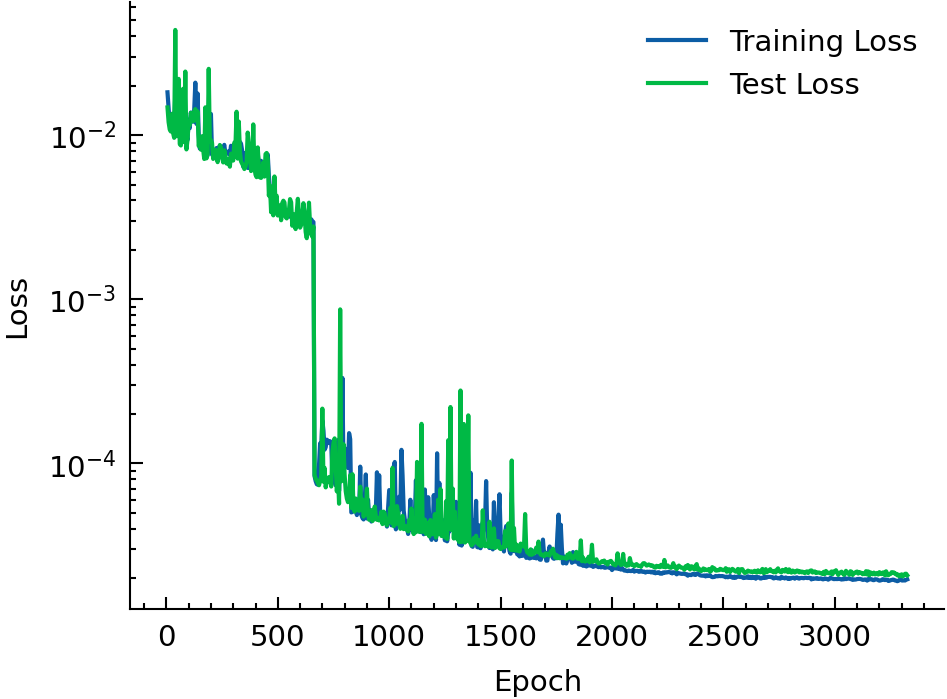

In [1]:
%reset -f

import torch
import numpy as np
from plpm import calculate_PLV, ModelWrapper, MainPlots
from plpm.classes.plots import color_cycle
import matplotlib.pyplot as plt
from plpm.constants.BaselineCase import base
from pkg_resources import resource_stream
import pandas as pd

space_dim = 10
model_file = 'MainModel10DFinal'

main_model = ModelWrapper.Model(model_file=model_file, d=space_dim)
loss_file = 'losses10DFinal'

figures = MainPlots()
figures.plot_loss(loss_file)



In [2]:
InvResults = pd.read_csv(resource_stream(
    'plpm', '../data/InvModeling/InvResults_Final.csv'),
    index_col=0)

MtcResults = pd.read_csv(resource_stream(
    'plpm', '../data/InvModeling/MtcResults_Final.csv'),
    index_col=0)

In [3]:
CASE_IDs = ['pig924baseline.csv', 'pig987baseline.csv', 'pig1605.csv', 'pig2455.csv',
            'pig2854baseline.csv', 'pig3072.csv', 'pig3802.csv', 'pig3946.csv']

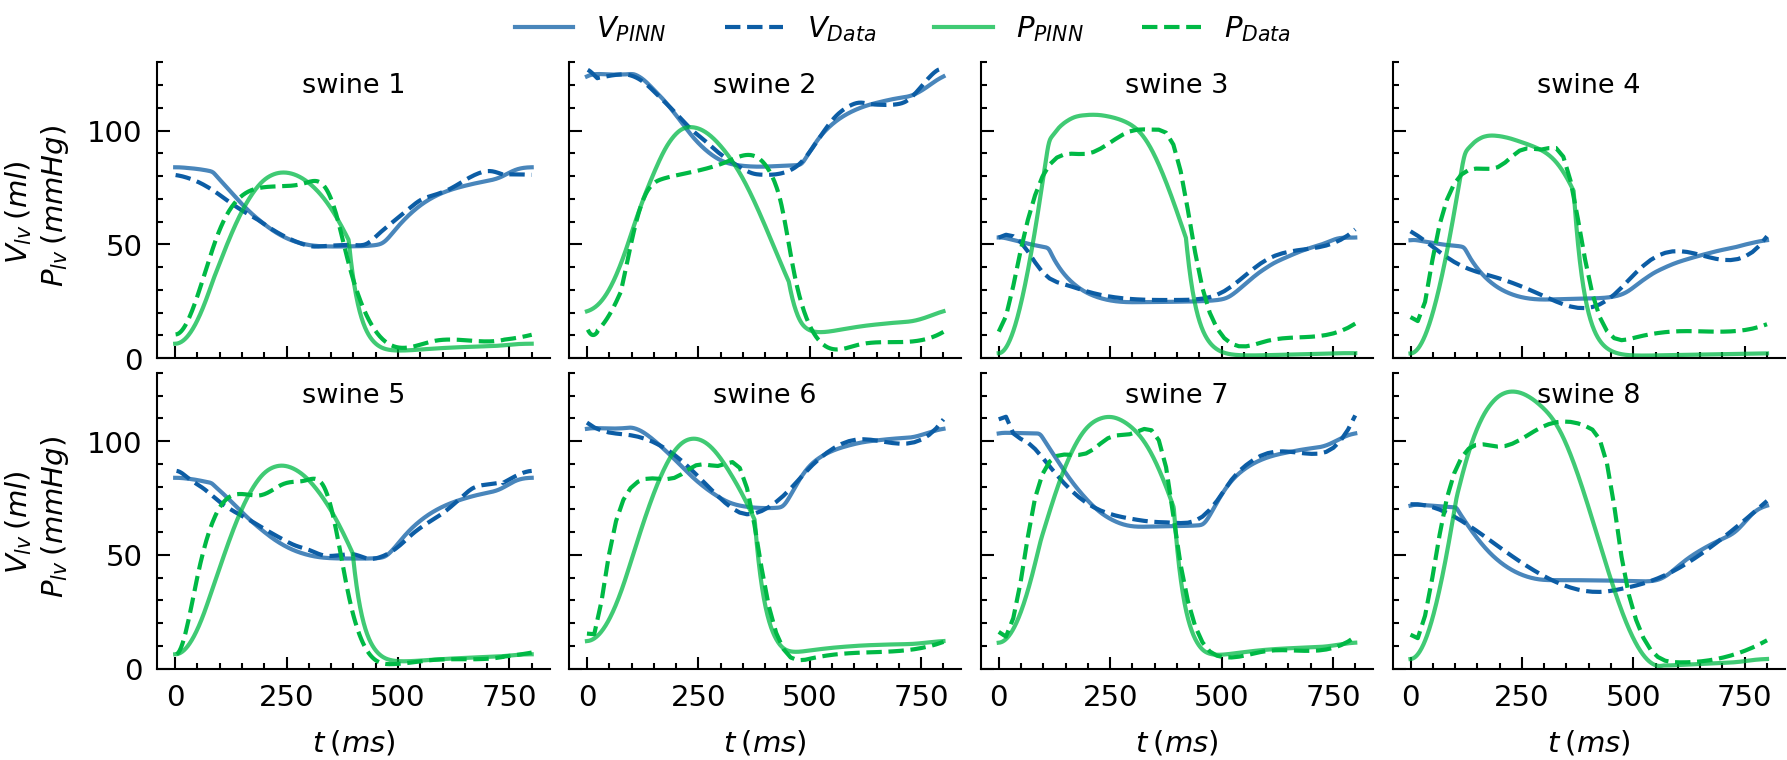

In [4]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(3.5 * 2., 2.625 * 1.))

for i in range(2):
    for j in range(4):
        counter = i * 4 + j
        CASE_ID = CASE_IDs[counter]
        CASE_Estimated = torch.tensor([InvResults.loc[CASE_ID]])
        metrics = torch.tensor([MtcResults.loc[CASE_ID]])
        data = np.loadtxt(resource_stream(
            'plpm', '../data/ExperimentalData/processed/'+ CASE_ID),
            delimiter=",", skiprows=1)
        t_data = data[:, 0]
        vlv_data = data[:, 1]
        Plv_data = data[:, 2]
        CASE = CASE_Estimated
        mR_av, mR_ao, mC_ao, mR_art, mC_art, mR_vc, mC_vc, mR_mv, mEes_lv, mtrans_lv = torch.split(CASE.squeeze(), 1, dim=0)
        V_pinn = main_model.predict_CASE(CASE_Estimated)
        plv_pinn = calculate_PLV(V_pinn[:, 0], mEes_lv, mtrans_lv)
        vlv_pinn = V_pinn[:, 0]
        t_pinn = torch.linspace(0., 1., vlv_pinn.shape[0]) * base.Tc
        ax[i, j].plot(t_pinn, vlv_pinn, alpha=0.75, label='$V_{PINN}$')
        ax[i, j].plot(t_data, vlv_data, label='$V_{Data}$', alpha=1.,
                    ls='--', color= color_cycle[0])
        ax[i, j].set_ylim(0, 130)
        ax[i, j].plot(t_pinn, plv_pinn, color= color_cycle[1], alpha=0.75,
                 label='$P_{PINN}$')
        ax[i, j].plot(t_data, Plv_data, color=color_cycle[1], alpha=1.,
                    label='$P_{Data}$', ls='--')
        
        if i == 0:
            ax[i, j].xaxis.set_ticklabels([])
        
        if j != 0:
            ax[i, j].yaxis.set_ticklabels([])
        ax[i, j].text(400, 120, f"swine {counter + 1}", fontsize=6.5, ha='center', va='center')

        
ax[1, 0].set_xlabel('$t \: (ms)$')
ax[1, 1].set_xlabel('$t \: (ms)$')
ax[1, 2].set_xlabel('$t \: (ms)$')
ax[1, 3].set_xlabel('$t \: (ms)$')
ax[0, 0].set_ylabel('$V_{lv} \: (ml)$ \n $P_{lv} \: (mmHg)$')
ax[1, 0].set_ylabel('$V_{lv} \: (ml)$ \n $P_{lv} \: (mmHg)$')

lines, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(lines, labels,
           loc='lower center',
           edgecolor='black', facecolor='white',
           ncol = 4, bbox_to_anchor=(0.48, .87))

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

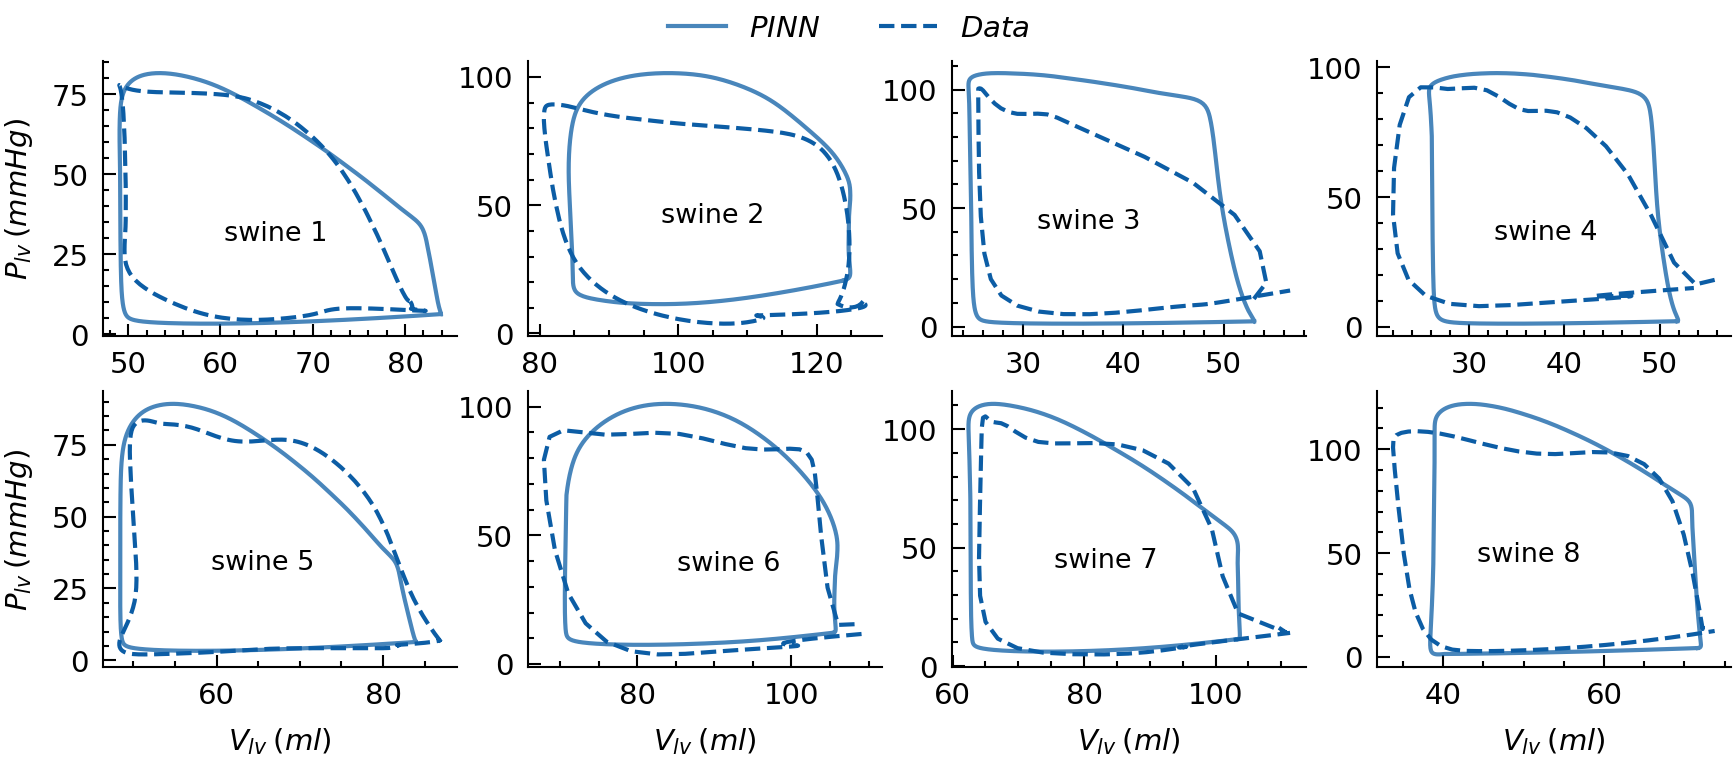

In [5]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(3.5 * 2., 2.625 * 1.))

for i in range(2):
    for j in range(4):
        counter = i * 4 + j
        CASE_ID = CASE_IDs[counter]
        CASE_Estimated = torch.tensor([InvResults.loc[CASE_ID]])
        metrics = torch.tensor([MtcResults.loc[CASE_ID]])
        data = np.loadtxt(resource_stream(
            'plpm', '../data/ExperimentalData/processed/'+ CASE_ID),
            delimiter=",", skiprows=1)
        t_data = data[:, 0]
        vlv_data = data[:, 1]
        Plv_data = data[:, 2]
        CASE = CASE_Estimated
        mR_av, mR_ao, mC_ao, mR_art, mC_art, mR_vc, mC_vc, mR_mv, mEes_lv, mtrans_lv = torch.split(CASE.squeeze(), 1, dim=0)
        V_pinn = main_model.predict_CASE(CASE_Estimated)
        plv_pinn = calculate_PLV(V_pinn[:, 0], mEes_lv, mtrans_lv)
        vlv_pinn = V_pinn[:, 0]
        ax[i, j].plot(vlv_pinn, plv_pinn, alpha=0.75, label='$PINN$')
        ax[i, j].plot(vlv_data, Plv_data, label='$Data$', alpha=1.,
                    ls='--', color= color_cycle[0])
        ax[i, j].text(vlv_pinn.mean(), plv_pinn.mean(), f"swine {counter + 1}", fontsize=6.5, ha='center', va='center')

        
ax[1, 0].set_xlabel('$V_{lv} \: (ml)$')
ax[1, 1].set_xlabel('$V_{lv} \: (ml)$')
ax[1, 2].set_xlabel('$V_{lv} \: (ml)$')
ax[1, 3].set_xlabel('$V_{lv} \: (ml)$')
ax[0, 0].set_ylabel('$P_{lv} \: (mmHg)$')
ax[1, 0].set_ylabel('$P_{lv} \: (mmHg)$')

lines, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(lines, labels,
           loc='lower center',
           edgecolor='black', facecolor='white',
           ncol = 2, bbox_to_anchor=(0.48, .87))

plt.show()

In [5]:
CASE_IDs2 = ['pig872baseline.csv', 'pig2873baseline.csv', 'pig2910baseline.csv',
             'pig872dobutamine.csv', 'pig2873dobutamine.csv', 'pig2910dobutamine.csv']

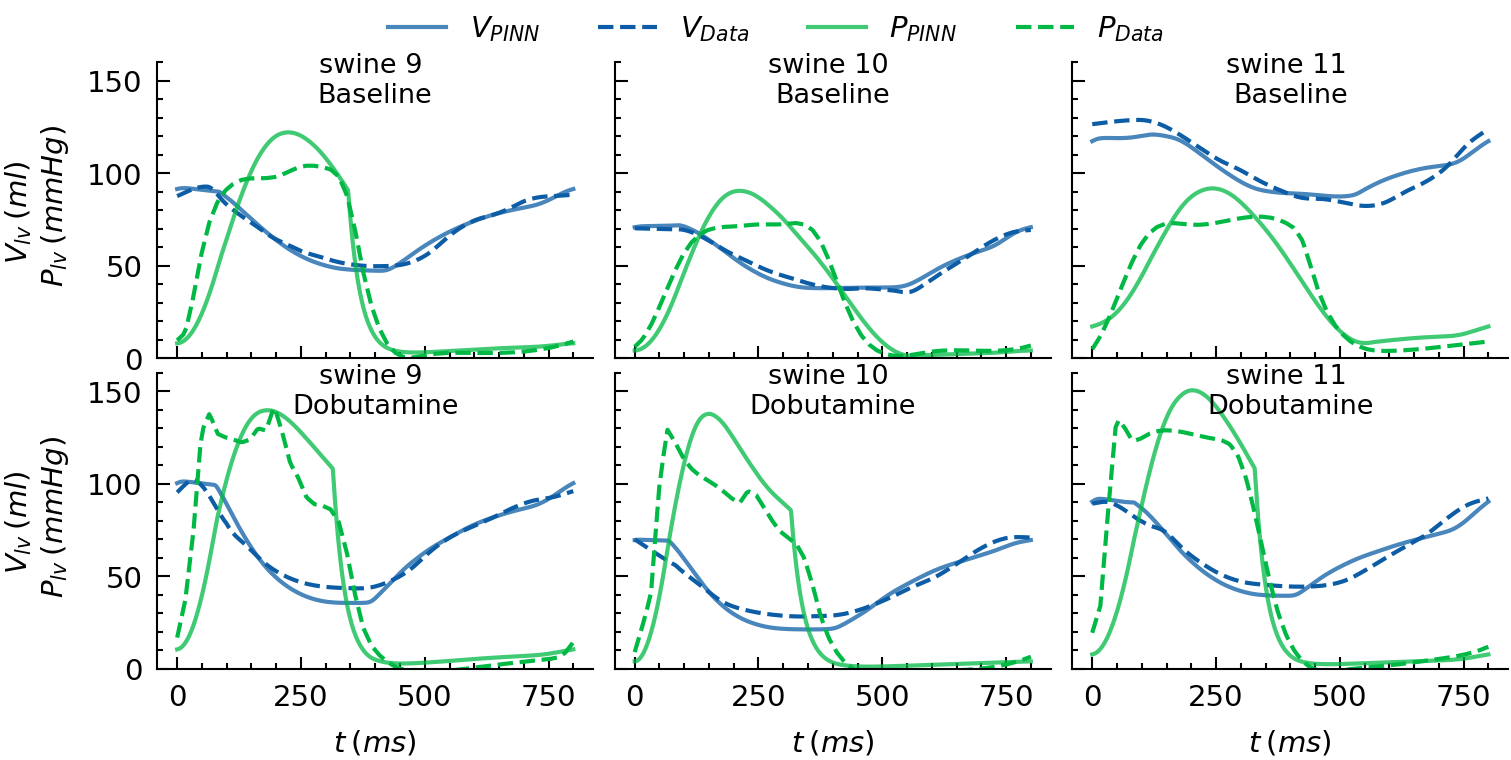

In [11]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(3.5 * 1.66, 2.625 * 1.))

for i in range(2):
    for j in range(3):
        counter = i * 3 + j
        CASE_ID = CASE_IDs2[counter]
        CASE_Estimated = torch.tensor([InvResults.loc[CASE_ID]])
        metrics = torch.tensor([MtcResults.loc[CASE_ID]])
        data = np.loadtxt(resource_stream(
            'plpm', '../data/ExperimentalData/processed/'+ CASE_ID),
            delimiter=",", skiprows=1)
        t_data = data[:, 0]
        vlv_data = data[:, 1]
        Plv_data = data[:, 2]
        CASE = CASE_Estimated
        mR_av, mR_ao, mC_ao, mR_art, mC_art, mR_vc, mC_vc, mR_mv, mEes_lv, mtrans_lv = torch.split(CASE.squeeze(), 1, dim=0)
        V_pinn = main_model.predict_CASE(CASE_Estimated)
        plv_pinn = calculate_PLV(V_pinn[:, 0], mEes_lv, mtrans_lv)
        vlv_pinn = V_pinn[:, 0]
        t_pinn = torch.linspace(0., 1., vlv_pinn.shape[0]) * base.Tc
        ax[i, j].plot(t_pinn, vlv_pinn, alpha=0.75, label='$V_{PINN}$')
        ax[i, j].plot(t_data, vlv_data, label='$V_{Data}$', alpha=1.,
                    ls='--', color= color_cycle[0])
        ax[i, j].set_ylim(0, 160)
        ax[i, j].plot(t_pinn, plv_pinn, color= color_cycle[1], alpha=0.75,
                 label='$P_{PINN}$')
        ax[i, j].plot(t_data, Plv_data, color=color_cycle[1], alpha=1.,
                    label='$P_{Data}$', ls='--')
        
        if i == 0:
            ax[i, j].xaxis.set_ticklabels([])
            ax[i, j].text(400, 150, f"swine {counter + 9} \nBaseline", fontsize=6.5, ha='center', va='center')
        
        if i == 1:
            ax[i, j].text(400, 150, f"swine {counter + 6} \nDobutamine", fontsize=6.5, ha='center', va='center')
        
        if j != 0:
            ax[i, j].yaxis.set_ticklabels([])

        
ax[1, 0].set_xlabel('$t \: (ms)$')
ax[1, 1].set_xlabel('$t \: (ms)$')
ax[1, 2].set_xlabel('$t \: (ms)$')
ax[0, 0].set_ylabel('$V_{lv} \: (ml)$ \n $P_{lv} \: (mmHg)$')
ax[1, 0].set_ylabel('$V_{lv} \: (ml)$ \n $P_{lv} \: (mmHg)$')

lines, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(lines, labels,
           loc='lower center',
           edgecolor='black', facecolor='white',
           ncol = 4, bbox_to_anchor=(0.48, .87))

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

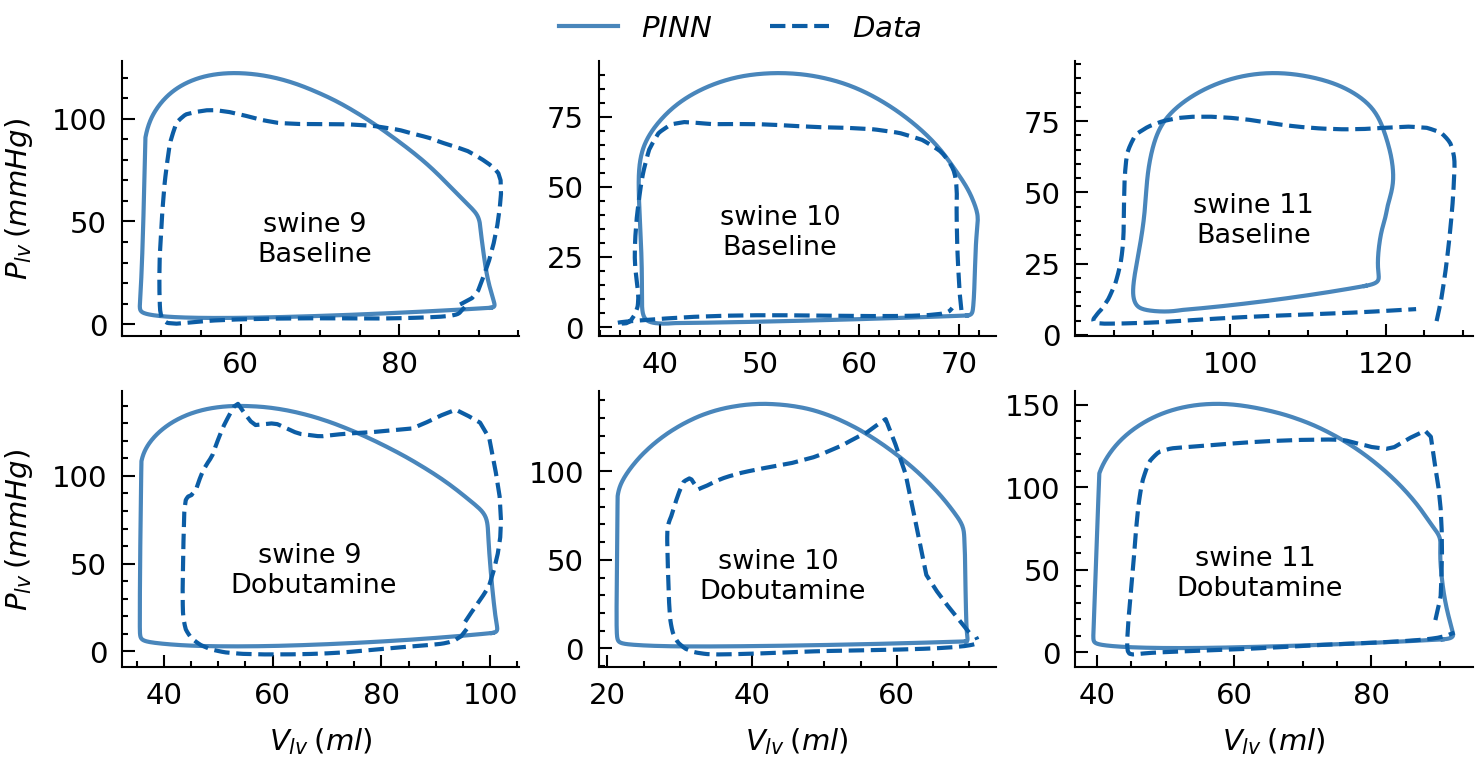

In [12]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(3.5 * 1.66, 2.625 * 1.))

for i in range(2):
    for j in range(3):
        counter = i * 3 + j
        CASE_ID = CASE_IDs2[counter]
        CASE_Estimated = torch.tensor([InvResults.loc[CASE_ID]])
        metrics = torch.tensor([MtcResults.loc[CASE_ID]])
        data = np.loadtxt(resource_stream(
            'plpm', '../data/ExperimentalData/processed/'+ CASE_ID),
            delimiter=",", skiprows=1)
        t_data = data[:, 0]
        vlv_data = data[:, 1]
        Plv_data = data[:, 2]
        CASE = CASE_Estimated
        mR_av, mR_ao, mC_ao, mR_art, mC_art, mR_vc, mC_vc, mR_mv, mEes_lv, mtrans_lv = torch.split(CASE.squeeze(), 1, dim=0)
        V_pinn = main_model.predict_CASE(CASE_Estimated)
        plv_pinn = calculate_PLV(V_pinn[:, 0], mEes_lv, mtrans_lv)
        vlv_pinn = V_pinn[:, 0]
        ax[i, j].plot(vlv_pinn, plv_pinn, alpha=0.75, label='$PINN$')
        ax[i, j].plot(vlv_data, Plv_data, label='$Data$', alpha=1.,
                    ls='--', color= color_cycle[0])
        if i == 0:
            ax[i, j].text(vlv_pinn.mean(), plv_pinn.mean(), f"swine {counter + 9}\nBaseline", fontsize=6.5, ha='center', va='center')
        if i == 1:
            ax[i, j].text(vlv_pinn.mean(), plv_pinn.mean(), f"swine {counter + 6} \nDobutamine", fontsize=6.5, ha='center', va='center')

        
ax[1, 0].set_xlabel('$V_{lv} \: (ml)$')
ax[1, 1].set_xlabel('$V_{lv} \: (ml)$')
ax[1, 2].set_xlabel('$V_{lv} \: (ml)$')
ax[0, 0].set_ylabel('$P_{lv} \: (mmHg)$')
ax[1, 0].set_ylabel('$P_{lv} \: (mmHg)$')

lines, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(lines, labels,
           loc='lower center',
           edgecolor='black', facecolor='white',
           ncol = 2, bbox_to_anchor=(0.48, .87))

plt.show()

In [10]:
CASE_IDs

['pig924baseline.csv',
 'pig987baseline.csv',
 'pig1605.csv',
 'pig2455.csv',
 'pig2854baseline.csv',
 'pig3072.csv',
 'pig3802.csv',
 'pig3946.csv']

In [11]:
CASE_IDs2

['pig872baseline.csv',
 'pig2873baseline.csv',
 'pig2910baseline.csv',
 'pig872dobutamine.csv',
 'pig2873dobutamine.csv',
 'pig2910dobutamine.csv']